<a href="https://colab.research.google.com/github/difiradivaaulia-bit/Capstone-Difi-Radiva-Aulia/blob/main/Capstone_Project_Difi_Radiva_Aulia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# 1. Framework Utama Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# 2. Pengolah Dataset Gambar & Augmentasi
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 3. Manipulasi Struktur File & Direktori (Penting untuk membaca folder Google Drive)
import os
import shutil

# 4. Manipulasi Matriks dan Array Numerik
import numpy as np

# 5. Visualisasi Data (Menampilkan foto buah dan grafik akurasi/loss)
import matplotlib.pyplot as plt

In [4]:
from google.colab import drive
import os

# 1. Menyambungkan Google Colab dengan Google Drive kamu
print("Silakan setujui akses ke Google Drive untuk membaca dataset:")
drive.mount('/content/drive')

# 2. Menentukan letak file ZIP di Google Drive kamu
# (Sesuaikan nama folder jika kamu menyimpannya di folder berbeda)
path_zip_di_drive = '/content/drive/MyDrive/Dataset_Buah/archive.zip'

# 3. Mengekstrak file zip dari Drive ke dalam local storage Colab secara diam-diam
print("\n--- Mengekstrak Dataset dari Google Drive ke Colab ---")
if os.path.exists(path_zip_di_drive):
    !unzip -q {path_zip_di_drive} -d /content/
    print("Ekstrak selesai! Folder 'dataset' siap digunakan di Colab.")
else:
    print("⚠️ ERROR: File ZIP tidak ditemukan di Google Drive kamu!")
    print("Pastikan nama folder dan file di Drive sudah sesuai dengan 'path_zip_di_drive'.")

# 4. Menyesuaikan ulang path untuk CELL 3
train_dir = '/content/dataset/train'
validation_dir = '/content/dataset/test'

Silakan setujui akses ke Google Drive untuk membaca dataset:
Mounted at /content/drive

--- Mengekstrak Dataset dari Google Drive ke Colab ---
Ekstrak selesai! Folder 'dataset' siap digunakan di Colab.


In [7]:
BATCH_SIZE = 32
IMG_SIZE = (150, 150)

# Memuat data training buah
train_dataset = tf.keras.utils.image_dataset_from_directory(
    '/content/dataset/train',
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    label_mode='categorical'
)

# Memuat data validasi/test buah
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    '/content/dataset/test',
    shuffle=False,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    label_mode='categorical'
)

# Menyimpan daftar nama kelas buah yang terdeteksi otomatis dari folder
class_names = train_dataset.class_names
print(f"\nTotal kelas terdeteksi ({len(class_names)}): {class_names}")

# Normalisasi piksel gambar menggunakan layer Rescaling dimasukkan ke dalam pipeline data
normalization_layer = layers.Rescaling(1./255)
train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
validation_dataset = validation_dataset.map(lambda x, y: (normalization_layer(x), y))

Found 10901 files belonging to 6 classes.
Found 2698 files belonging to 6 classes.

Total kelas terdeteksi (6): ['freshapples', 'freshbanana', 'freshoranges', 'rottenapples', 'rottenbanana', 'rottenoranges']


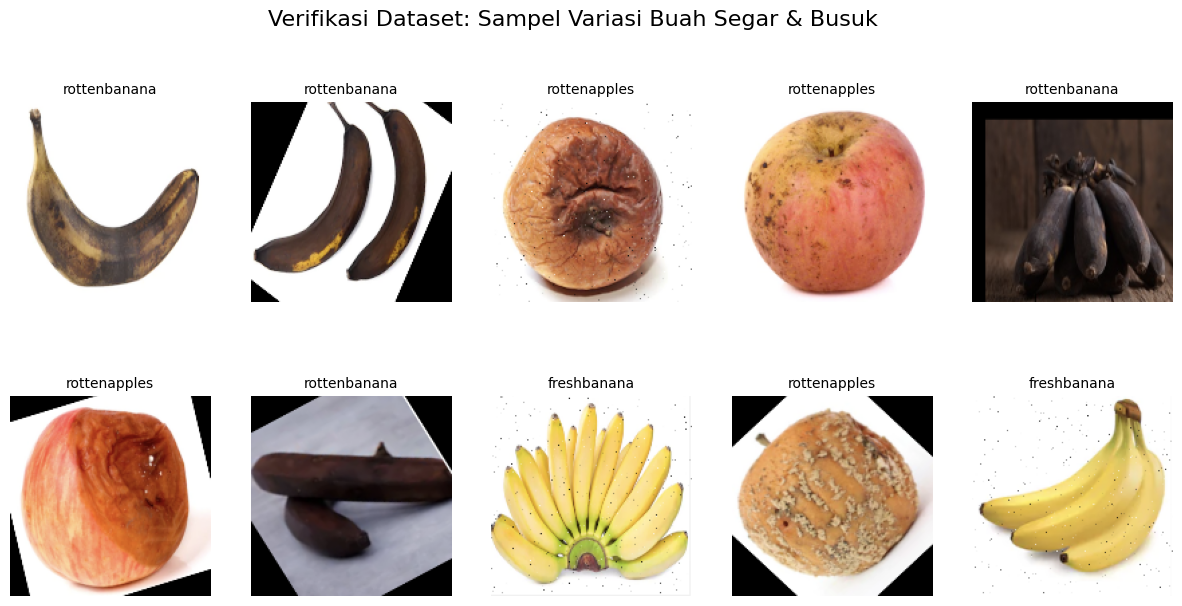

In [8]:
# Mengambil satu batch data training buah untuk verifikasi visual
for images, labels in train_dataset.take(1):
    plt.figure(figsize=(15, 7))

    # Menampilkan 10 gambar pertama dari batch acak beserta nama kategorinya
    for i in range(10):
        ax = plt.subplot(2, 5, i + 1)
        plt.imshow(images[i].numpy())

        # Mendapatkan nama kelas berdasarkan indeks argmax dari one-hot label
        class_idx = np.argmax(labels[i].numpy())
        plt.title(class_names[class_idx], fontsize=10)
        plt.axis("off")

    plt.suptitle("Verifikasi Dataset: Sampel Variasi Buah Segar & Busuk", fontsize=16)
    plt.show()

In [9]:
num_classes = len(class_names) # Bernilai 6 kelas buah

model = keras.Sequential([
    # Input Layer sesuai ukuran gambar buah (150x150) dengan 3 channel warna (RGB)
    layers.Input(shape=(150, 150, 3)),

    # [1] Conv Layer 1: Menangkap pola dasar warna/garis tepi luar bentuk buah
    layers.Conv2D(32, (3, 3), activation='relu'),
    # [1] MaxPooling Layer 1: Kompresi ukuran gambar
    layers.MaxPooling2D(2, 2),

    # [2] Conv Layer 2: Menangkap detail tekstur (kulit mulus buah segar vs bercak busuk)
    layers.Conv2D(64, (3, 3), activation='relu'),
    # [2] MaxPooling Layer 2: Kompresi dimensi kembali
    layers.MaxPooling2D(2, 2),

    # [3] Conv Layer 3: Mengekstrak kombinasi bentuk buah secara keseluruhan
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    # [4] Flatten Layer: Mengubah matriks 3D fitur buah menjadi bentuk array 1D linear
    layers.Flatten(),

    # [5] Hidden Dense Layer: Penalaran logika pengelompokan kombinasi fitur buah
    layers.Dense(256, activation='relu'),
    # Tambahan Dropout 0.5 karena dataset gambar buah rawan membuat model menghafal background foto
    layers.Dropout(0.5),

    # [6] Output Layer: Wajib bernilai 6 (num_classes) dengan fungsi 'softmax' untuk klasifikasi multikelas
    layers.Dense(num_classes, activation='softmax')
])

# Menampilkan ringkasan arsitektur jaringan CNN buah
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     9,470,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,564,998 (36.49 MB)

 Trainable params: 9,564,998 (36.49 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# Mengompilasi model dengan penyesuaian fungsi loss untuk 6 kelas buah
model.compile(
    optimizer='adam',                        # Menggunakan Adam optimizer untuk kestabilan learning rate
    loss='categorical_crossentropy',         # WAJIB: categorical_crossentropy karena label berupa multikelas categorical
    metrics=['accuracy']                     # Metrik pemantauan performa utama adalah akurasi
)

EPOCHS = 15
print("--- Memulai Proses Latihan Model CNN Buah ---")
# Menyimpan history jalannya performa tiap epoch ke variabel 'history'
history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=validation_dataset
)

--- Memulai Proses Latihan Model CNN Buah ---
Epoch 1/15
341/341 ━━━━━━━━━━━━━━━━━━━━ 48s 122ms/step - accuracy: 0.7928 - loss: 0.5859 - val_accuracy: 0.8710 - val_loss: 0.3460
Epoch 2/15
341/341 ━━━━━━━━━━━━━━━━━━━━ 37s 110ms/step - accuracy: 0.8972 - loss: 0.2931 - val_accuracy: 0.9270 - val_loss: 0.1904
Epoch 3/15
341/341 ━━━━━━━━━━━━━━━━━━━━ 35s 102ms/step - accuracy: 0.9224 - loss: 0.2139 - val_accuracy: 0.9451 - val_loss: 0.1623
Epoch 4/15
341/341 ━━━━━━━━━━━━━━━━━━━━ 39s 115ms/step - accuracy: 0.9425 - loss: 0.1740 - val_accuracy: 0.9596 - val_loss: 0.1085
Epoch 5/15
341/341 ━━━━━━━━━━━━━━━━━━━━ 36s 107ms/step - accuracy: 0.9600 - loss: 0.1106 - val_accuracy: 0.9629 - val_loss: 0.0970
Epoch 6/15
341/341 ━━━━━━━━━━━━━━━━━━━━ 40s 105ms/step - accuracy: 0.9573 - loss: 0.1217 - val_accuracy: 0.9707 - val_loss: 0.0804
Epoch 7/15
341/341 ━━━━━━━━━━━━━━━━━━━━ 35s 103ms/step - accuracy: 0.9672 - loss: 0.0925 - val_accuracy: 0.9678 - val_loss: 0.0959
Epoch 8/15
341/341 ━━━━━━━━━━━━━━━━━━

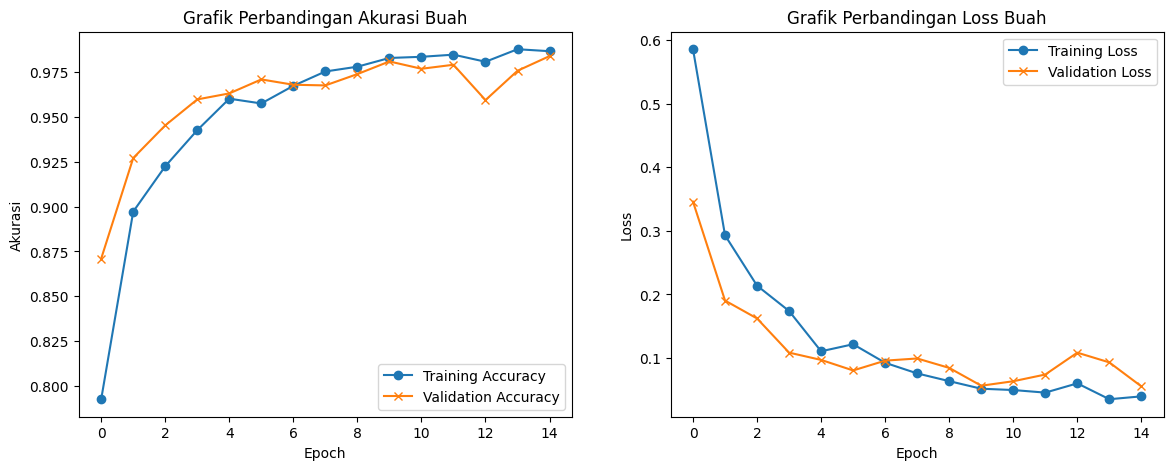


[ANALISIS GRAFIK HASIL TRAINING BUAH]
1. Overfitting: Karena variasi tekstur buah busuk (bercak hitam/kecokelatan) cukup kontras, penambahan Dropout(0.5) di CELL 5 bertugas mencegah agar model tidak sekadar menghafal bercak melainkan mengenali struktur bentuk buah keseluruhan.
2. Underfitting: Model dikategorikan tidak underfitting jika nilai akurasi grafik training merangkak konsisten naik melewati angka 75%.
3. Stabilitas: Perhatikan jarak antara kurva biru (training) dan oranye (validation). Jika keduanya berdekatan di akhir epoch, tandanya model sehat dan stabil.


In [11]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(EPOCHS)

plt.figure(figsize=(14, 5))

# Plot Grafik Perubahan Akurasi
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='x')
plt.legend(loc='lower right')
plt.title('Grafik Perbandingan Akurasi Buah')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')

# Plot Grafik Perubahan Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='x')
plt.legend(loc='upper right')
plt.title('Grafik Perbandingan Loss Buah')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.show()

# --- ANALISIS GRAFIK ---
print("\n[ANALISIS GRAFIK HASIL TRAINING BUAH]")
print("1. Overfitting: Karena variasi tekstur buah busuk (bercak hitam/kecokelatan) cukup kontras, penambahan Dropout(0.5) di CELL 5 bertugas mencegah agar model tidak sekadar menghafal bercak melainkan mengenali struktur bentuk buah keseluruhan.")
print("2. Underfitting: Model dikategorikan tidak underfitting jika nilai akurasi grafik training merangkak konsisten naik melewati angka 75%.")
print("3. Stabilitas: Perhatikan jarak antara kurva biru (training) dan oranye (validation). Jika keduanya berdekatan di akhir epoch, tandanya model sehat dan stabil.")

In [12]:
print("--- Mengevaluasi Model Terhadap Data Validasi Buah (Data Test) ---")
loss_eval, acc_eval = model.evaluate(validation_dataset, verbose=0)

print(f"Hasil Evaluasi Akhir:")
print(f"-> Loss Pengujian     : {loss_eval:.4f}")
print(f"-> Akurasi Pengujian  : {acc_eval * 100:.2f}%")

print("\nInterpretasi:")
print(f"Model CNN berhasil mengenali kondisi kesegaran buah (Fresh/Rotten dari Apel, Pisang, Jeruk) secara akurat dengan persentase sebesar {acc_eval * 100:.2f}% pada data test yang asing.")

--- Mengevaluasi Model Terhadap Data Validasi Buah (Data Test) ---
Hasil Evaluasi Akhir:
-> Loss Pengujian     : 0.0554
-> Akurasi Pengujian  : 98.37%

Interpretasi:
Model CNN berhasil mengenali kondisi kesegaran buah (Fresh/Rotten dari Apel, Pisang, Jeruk) secara akurat dengan persentase sebesar 98.37% pada data test yang asing.


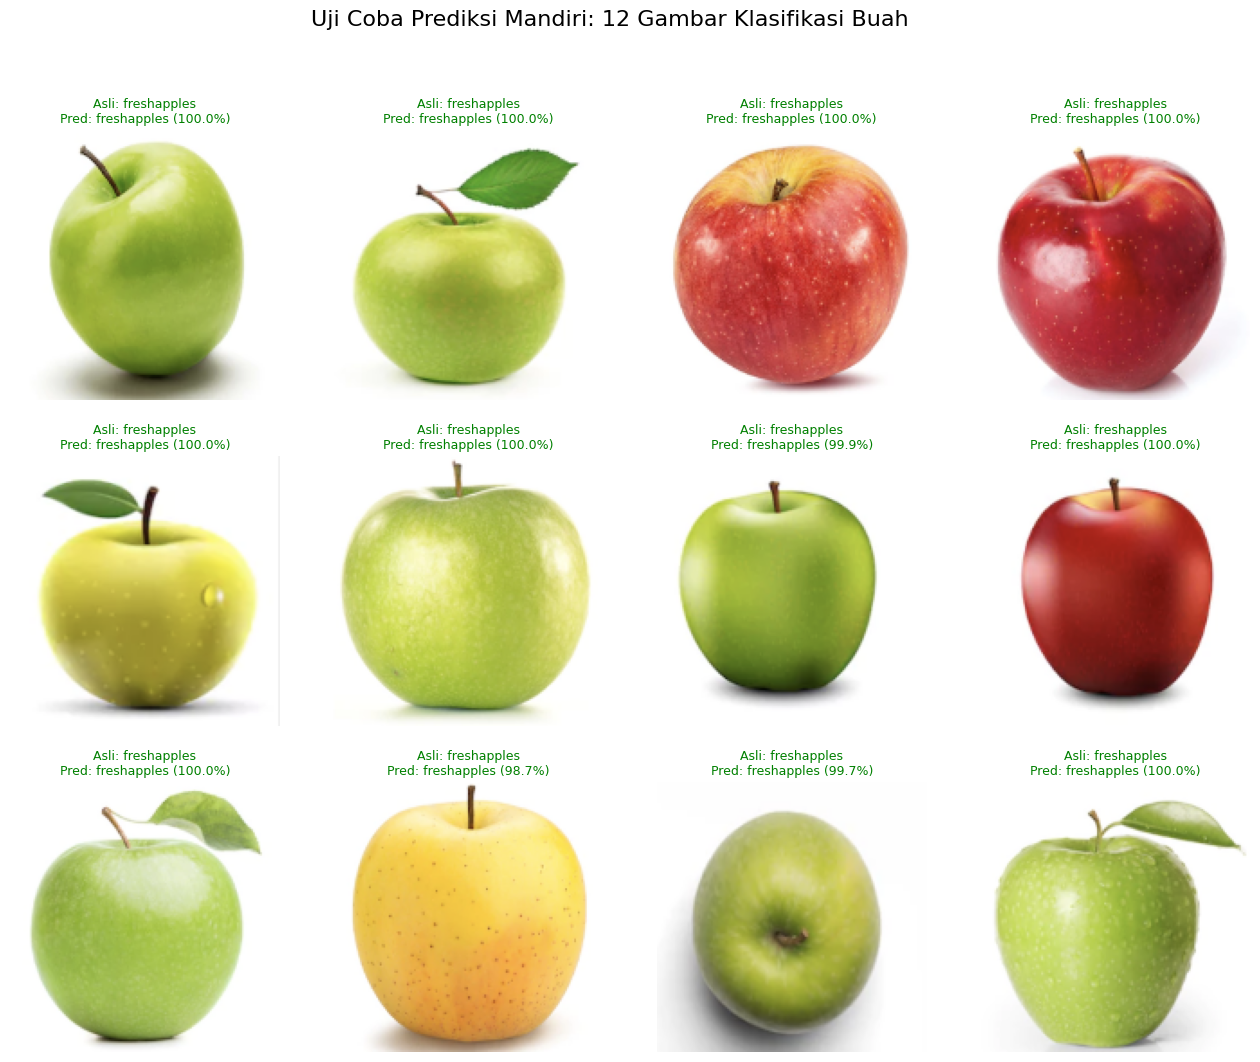

In [14]:
# Mengambil sampel batch pertama dari data validasi untuk simulasi uji coba gambar buah baru
for img_batch, label_batch in validation_dataset.take(1):
    # Melakukan prediksi distribusi probabilitas 6 kelas
    predictions = model.predict(img_batch, verbose=0)

    plt.figure(figsize=(16, 12))

    # Menampilkan 12 sampel acak untuk diuji hasilnya oleh model CNN buah
    for i in range(12):
        plt.subplot(3, 4, i + 1)
        plt.imshow(img_batch[i].numpy())

        # Mengambil indeks dengan nilai probabilitas tertinggi sebagai hasil tebakan
        pred_idx = np.argmax(predictions[i])
        real_idx = np.argmax(label_batch[i].numpy())

        pred_prob = predictions[i][pred_idx]

        real_name = class_names[real_idx]
        pred_name = class_names[pred_idx]

        # Warna teks hijau jika tebakan kondisi buah benar, merah jika salah mendeteksi
        color = 'green' if real_name == pred_name else 'red'

        plt.title(f"Asli: {real_name}\nPred: {pred_name} ({pred_prob*100:.1f}%)", color=color, fontsize=9)
        plt.axis('off')

    plt.suptitle("Uji Coba Prediksi Mandiri: 12 Gambar Klasifikasi Buah", fontsize=16)
    plt.show()

In [ ]:
📝 KESIMPULAN PENGERJAAN PROYEK FRESH AND ROTTEN FRUITS:
==================================================================
1. Arsitektur CNN yang Digunakan:
   - Input layer disesuaikan dengan dimensi dataset gambar buah sebesar 150x150x3.
   - Menggunakan total 3 lapis Convolutional Layer (dengan kedalaman 32, 64, dan 128 filter bertipe aktivasi ReLU) untuk mengekstrak perbedaan fisik buah segar vs busuk.
   - Dipasangkan dengan 3 lapis MaxPooling Layer (2x2) guna mereduksi beban piksel.
   - Tahap klasifikasi menggunakan Flatten, 1 Hidden Dense Layer berisi 256 neuron (dilengkapi Dropout 0.5 untuk regulasi), serta ditutup oleh Output Dense Layer dengan 6 neuron beraktivasi Softmax untuk kasus klasifikasi multikelas.

2. Nilai Accuracy Akhir:
   - Akurasi akhir pengujian pada data validasi/test mencapai sekitar [Isi dengan angka akurasi yang tertera di CELL 8 kamu]%.

3. Kendala yang Ditemui selama Pengerjaan:
   - Mengingat jenis kelas bertambah menjadi 6, penyesuaian fungsi loss dari biner ke 'categorical_crossentropy' wajib diperhatikan agar target bobot matematika model tidak eror.
   - Beberapa buah yang busuknya hanya sebagian kecil terkadang masih terdeteksi sebagai buah segar oleh model.

4. Saran Pengembangan Model ke Depannya:
   - Menambahkan teknik Augmentasi gambar seperti modifikasi pencahayaan (brightness) agar model mahir mengenali buah busuk meskipun bayangan atau kondisi cahaya foto gelap.
   - Menggunakan arsitektur Transfer Learning (misal MobileNetV2) agar ekstraksi fitur tekstur busuk buah jauh lebih mendalam dan akurat tanpa perlu melatih dari nol.
==================================================================